## [TECHNICAL NOTEBOOK] Project: Inflation Volatility & Risk Analysis

**Target:** Office of the Gorvernor, Central Bank of Kenya

**Analyst:** Stephen Munene (Policy unit)

**Date:** March 2026

### 1.Business & Economic Understanding

The primary mandate of the Central Bank of Kenya(CBK) is to maintain price stability.

Currently, the target inflation range is $5.0\% \pm 2.5\%$

**Objective:** These notebook performs a statistical audit of Kenya's inflation history (1960-2024).We use "Data DNA"(Mean, Standard_Deviation, Z-scores) to:

    1. Identify the "Black Swan" events (High-risk anomalies).

    2. Determine if the distribution is "Normal" or "Fat-Tailed"(skewed by extreme shocks).
    
    3. Provide a quantitative baseline for future Monetary Policy Committee(MPC) decisions.

### 2. Data Preparation & Environment

We use standard quantitative stacks. We apply the **ggplot** style for clean, academic grade visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Set aesthetic parameters for a professional report
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

# Loading the dataset
df = pd.read_csv('kenya_inflation_data.csv')

### 3. Exploratory Data Analysis(EDA) & Data DNA

Before modeling we must understand the "DNA" of our currency's purchasing power.

In [2]:
# Calculating the 'DNA' metrics
mu = df["inflation"].mean()
sigma = df["inflation"].std()

print(f"Historical Mean (μ): {mu:.2f}%")
print(f"Historical Volatility (σ): {sigma:.2f}%")

Historical Mean (μ): 9.70%
Historical Volatility (σ): 7.98%


**Analytical Note:**

A Standard Deviation of 7.98% against a Mean of 9.70% indicates **High Volatility**.In a stable economy, we would expect $\sigma$ to be much lower (2–3%). This suggests Kenya's inflation is prone to external and internal shocks (droughts, oil prices ,policy shifts)

### 4. Risk Analysis: The Z-Score Framework

We use the Z-score to transform raw percentages into "Units of Risk".
- **Z > 2:** Extreme Inflationary Pressure (Top 2.5% of historical cases).
- **Z <- 2:** Significant Deflationary Pressure(Rare in Kenya).

In [3]:
# Feature Engineering: Z-Score and Risk Categorization
df['z_score'] = (df['inflation'] - mu) / sigma

# Define Risk Flags based on 2-Sigma Thresholds
df["risk_status"] = df["z_score"].apply(
    lambda x: "Extreme Outlier" if abs(x) > 2 else "Manageable"
)

# Identifying the "Crisis Years"
crises = df[df["risk_status"] == "Extreme Outlier"]
display(crises[['year', 'inflation', 'z_score']])

,year,inflation,z_score
32,1992,27.332364,2.209214
33,1993,45.978881,4.545823
34,1994,28.814389,2.394928
48,2008,26.239817,2.072306


### 5. Visualizing the Distribution (The "Policy Gap")

   As an analyst, I need to see if the data follows a **Normal Distribution.** If it doesn't, standard "avarage" policy won't work. 


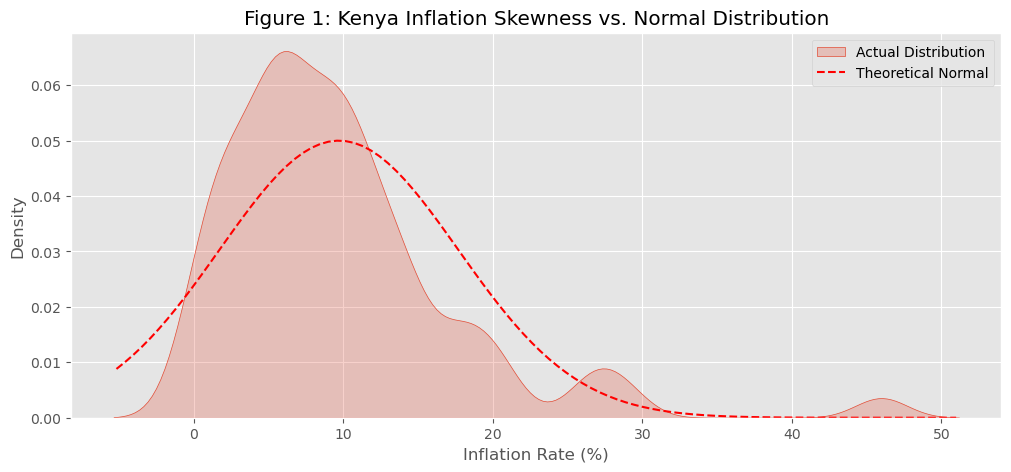

In [4]:
plt.figure(figsize=(12, 5))

# Plot 1: The Probability Density
sns.kdeplot(df['inflation'], bw_adjust=0.5, fill=True, label="Actual Distribution")

# Plot 2: The Theoretical Normal Curve for comparison
x = np.linspace(df['inflation'].min() - 5, df['inflation'].max() + 5, 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r--', label="Theoretical Normal")

plt.title("Figure 1: Kenya Inflation Skewness vs. Normal Distribution")
plt.xlabel("Inflation Rate (%)")
plt.legend()
plt.show()

**Insight for the Governor:**

Our distribution is **Positively skewed** (Right-skewed). This means Kenya is more likely to experience "Hyper-Inflationary Shocks" (like the 45% in 1993) than it is to experience equivalent deflation. Policy must therefore be structurally biased toward "Hawkish" inflation containment.

### 6. Historical Time-Series Risk Map

This the "Money Shot" for the memorandum. It shows exactly when the economy broke the 2-Sigma barrier.

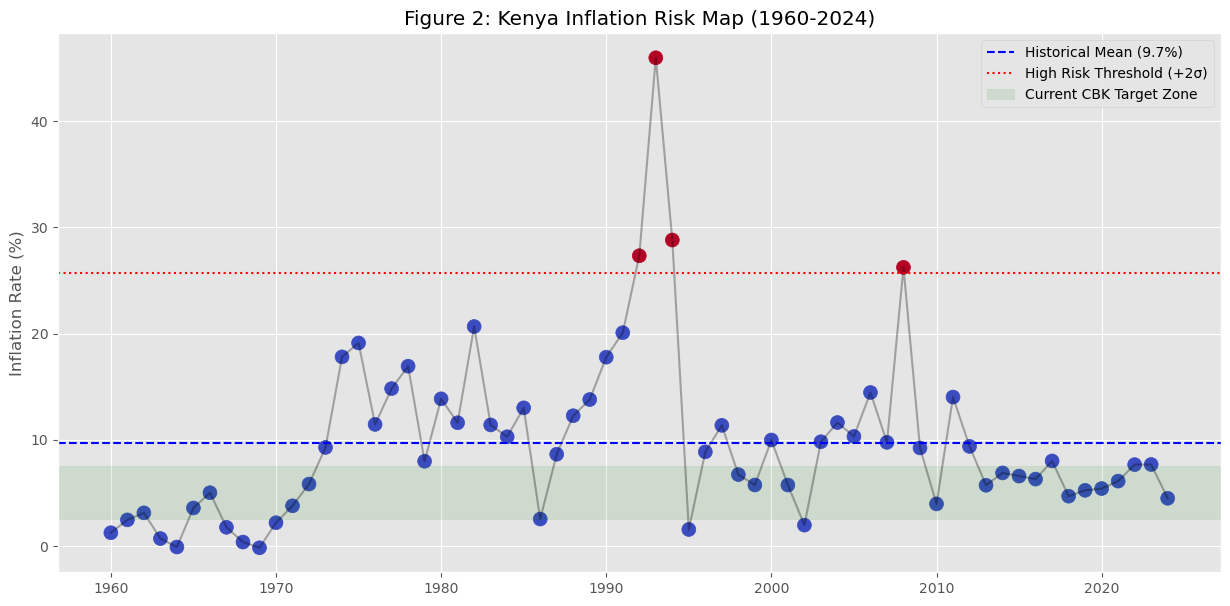

In [5]:
plt.figure(figsize=(15, 7))
plt.plot(df["year"], df["inflation"], color='black', alpha=0.3)
plt.scatter(df["year"], df["inflation"], c=(abs(df['z_score']) > 2), cmap='coolwarm', s=100)

# Critical Policy Lines
plt.axhline(mu, color='blue', linestyle='--', label=f'Historical Mean ({mu:.1f}%)')
plt.axhline(mu + 2*sigma, color='red', linestyle=':', label='High Risk Threshold (+2σ)')
plt.axhspan(2.5, 7.5, color='green', alpha=0.1, label='Current CBK Target Zone')

plt.title("Figure 2: Kenya Inflation Risk Map (1960-2024)")
plt.ylabel("Inflation Rate (%)")
plt.legend()
plt.show()

### 7. Final Recommendations for the Memorandum

Based on the notebook Analysis:

**1. Anomaly Detection:** 1993 remains the most significant outlier in Kenya's history ($Z \approx 4.5$).

**2. Volatility Warning:** Because our Standard Deviation (7.98) is nearly as large as our Mean (9.7), the CBK must maintain higher-than-avarage reserves to buffer against "2-Sigma" shocks.

**3. Target Realism:** The current target of 7.5% is significantly below the 65-year historical  mean, suggesting a mordern era of much tighter monetary discipline compared to the 20th century.

<div style="padding: 15px; border: 1px solid #e1e4e8; border-radius: 6px; background-color: #f6f8fa;">
    <h4 style="margin-top: 0; color: #d73a49;">⚠️ Non-Affiliation Disclaimer</h4>
    <p style="font-size: 0.9em; color: #586069;">
        This notebook is an <strong>independent technical exercise</strong> and is not 
        commissioned by, nor affiliated with, the Central Bank of Kenya (CBK). 
        The "Policy Analyst" persona is used strictly for simulated business context. 
        <strong>No official endorsement is implied.</strong>
    </p>
</div>